Loading the modules

In [7]:
from sklearn import datasets
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

Loading the Dataset

In [8]:
iris = datasets.load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Split Data to Train and Test

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.4, random_state=42
)

Train SVM

In [10]:
svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)
svm_acc = accuracy_score(y_test, svm_pred)

Train KNN

In [11]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
knn_pred = knn_model.predict(X_test)
knn_acc = accuracy_score(y_test, knn_pred)

Comparing their Capacities

In [12]:
print(f"SVM Accuracy: {svm_acc:.2f}")
print(f"k-NN Accuracy: {knn_acc:.2f}")

SVM Accuracy: 1.00
k-NN Accuracy: 0.98


Create a Confusion Matrix (for one model)

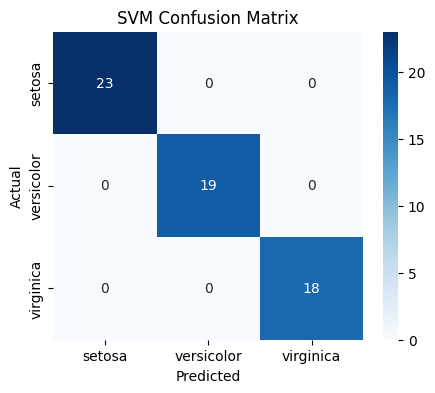

In [13]:
cm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SVM Confusion Matrix')
plt.show()

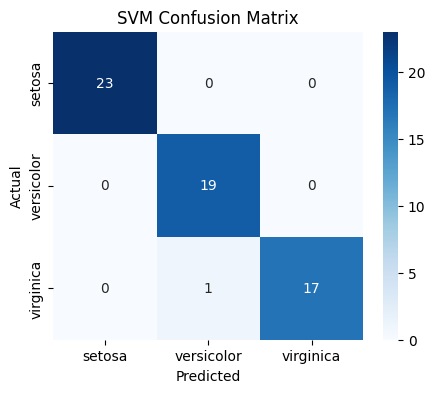

In [14]:
cm = confusion_matrix(y_test, knn_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SVM Confusion Matrix')
plt.show()

SVM (linear) test accuracy: 0.933
k-NN (k=5)   test accuracy: 0.933


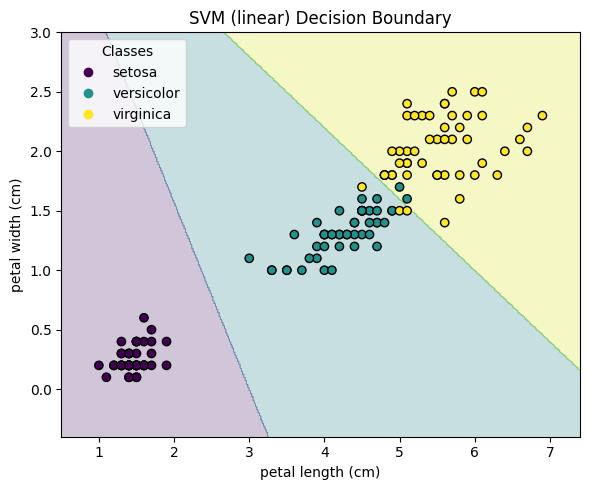

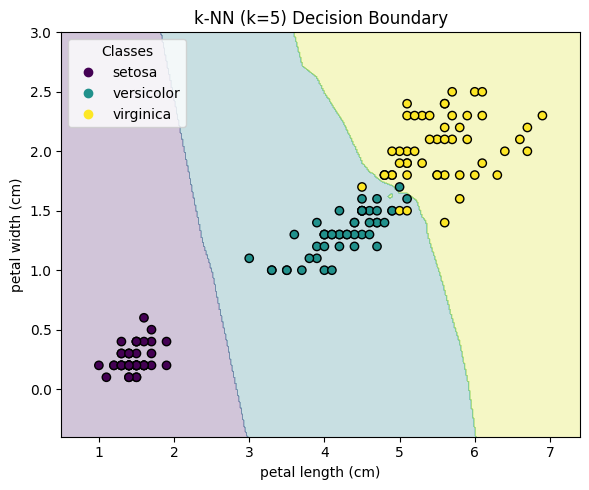

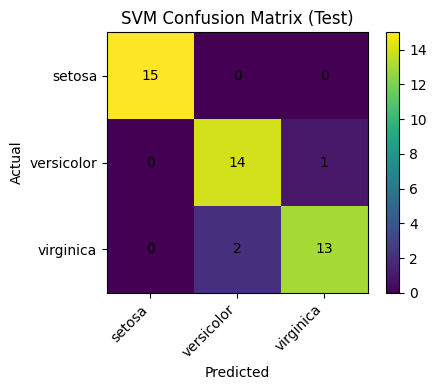

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# 1) Data: use two features for 2D boundaries (petal length, petal width)
iris = datasets.load_iris()
feature_idxs = [2, 3]  # petal length (cm), petal width (cm)
X = iris.data[:, feature_idxs]
y = iris.target
feat_names = [iris.feature_names[i] for i in feature_idxs]
class_names = iris.target_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# 2) Train models
svm_clf = SVC(kernel='linear', C=1, random_state=42)
svm_clf.fit(X_train, y_train)

knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train, y_train)

# 3) Compute accuracies
svm_acc = accuracy_score(y_test, svm_clf.predict(X_test))
knn_acc = accuracy_score(y_test, knn_clf.predict(X_test))
print(f"SVM (linear) test accuracy: {svm_acc:.3f}")
print(f"k-NN (k=5)   test accuracy: {knn_acc:.3f}")

# 4) Helper: plot decision boundary
def plot_decision_boundary(model, X, y, title, xlab, ylab):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(y_min, y_max, 400)
    )
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    plt.figure(figsize=(6, 5))
    # Background decision regions
    plt.contourf(xx, yy, Z, alpha=0.25)
    # Data points
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
    plt.xlabel(xlab)
    plt.ylabel(ylab)
    plt.title(title)
    # Legend using class names
    handles, _ = scatter.legend_elements()
    plt.legend(handles, class_names, title="Classes", loc="best")
    plt.tight_layout()
    plt.show()

# 5) Plots: SVM and k-NN boundaries (using the WHOLE set for clearer picture)
plot_decision_boundary(
    svm_clf, X, y,
    title="SVM (linear) Decision Boundary",
    xlab=feat_names[0], ylab=feat_names[1]
)

plot_decision_boundary(
    knn_clf, X, y,
    title="k-NN (k=5) Decision Boundary",
    xlab=feat_names[0], ylab=feat_names[1]
)

# 6) (Bonus) Confusion matrix for SVM on test set
cm = confusion_matrix(y_test, svm_clf.predict(X_test))
plt.figure(figsize=(5, 4))
plt.imshow(cm, interpolation='nearest')
plt.title("SVM Confusion Matrix (Test)")
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45, ha='right')
plt.yticks(tick_marks, class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Add counts on cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()


SVM (linear) Test Accuracy: 0.887


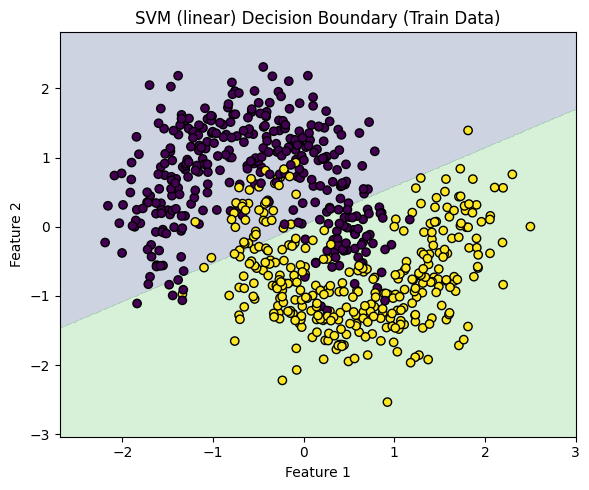

SVM (RBF) Test Accuracy: 0.963


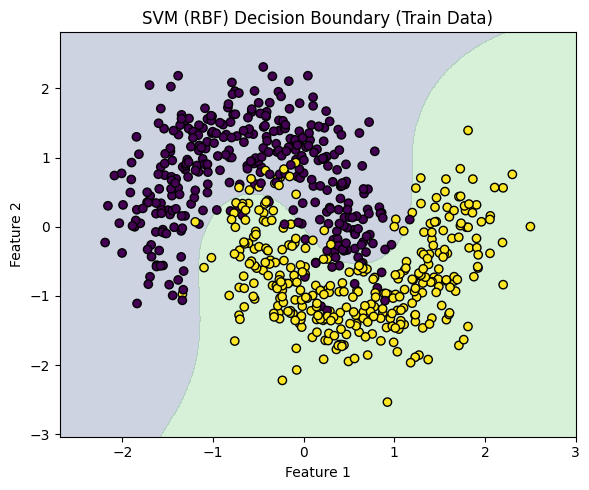

k-NN (k=15) Test Accuracy: 0.970


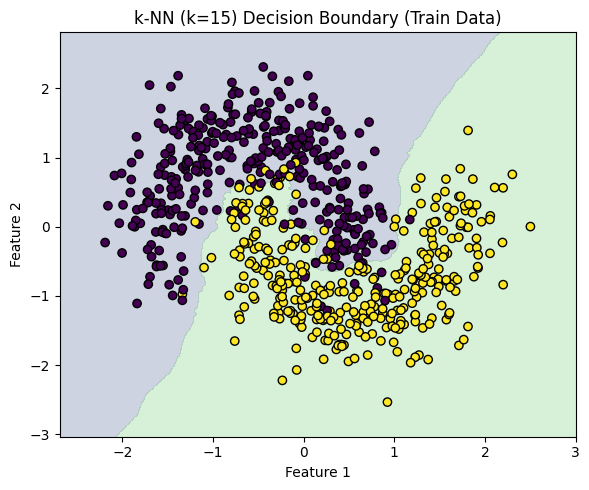

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# 1) Load Two Moons dataset
X, y = make_moons(n_samples=1000, noise=0.25, random_state=42)

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Scale features (important for SVM & k-NN)
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s  = scaler.transform(X_test)

# 2) Define models
models = {
    "SVM (linear)": SVC(kernel="linear", C=1.0, random_state=42),
    "SVM (RBF)":    SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42),
    "k-NN (k=5)":  KNeighborsClassifier(n_neighbors=5, weights="distance"),
    "k-NN (k=15)":  KNeighborsClassifier(n_neighbors=15, weights="distance"),
    "k-NN (k=20)":  KNeighborsClassifier(n_neighbors=20, weights="distance")
}

# 3) Helper: plot decision boundary
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                         np.linspace(y_min, y_max, 500))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    plt.figure(figsize=(6,5))
    plt.contourf(xx, yy, Z, alpha=0.25, levels=np.arange(y.max()+2)-0.5)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.tight_layout()
    plt.show()

# 4) Train, evaluate, and plot each model
for name, model in models.items():
    model.fit(X_train_s, y_train)
    acc = accuracy_score(y_test, model.predict(X_test_s))
    print(f"{name} Test Accuracy: {acc:.3f}")
    plot_decision_boundary(model, X_train_s, y_train, f"{name} Decision Boundary (Train Data)")
